# Exploration des dalles LiDAR HD — Saint-Blaise

**Objectif** : inspecter les 54 dalles IGN LiDAR HD téléchargées.
- Couverture spatiale (carte Lambert 93)
- Statistiques par dalle (points, altitude, taille)
- Distribution des classifications de points sur une dalle centrale

Ce notebook reste dans `explore/` — phase exploratoire uniquement.  
Le traitement validé sera converti en `src/lidar_arch/data/pipeline.py`.

In [ ]:
import re
from pathlib import Path

import laspy
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DALLES_DIR = Path("../data/raw/lidar/saint_blaise")
REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)

# Dalle d'exemple pour l'inspection détaillée
DALLE_CENTRALE = "LHD_FXX_0860_6265_PTS_C_LAMB93_IGN69.copc.laz"


## 0. Découverte des classifications

Scan de toutes les dalles pour inventorier les codes réellement utilisés.  
**Exécuter avant de remplir `CLASSIFICATIONS`.**

In [9]:
all_classes: set[int] = set()

for path in sorted(DALLES_DIR.glob("*.laz")):
    with laspy.open(path) as f:
        for chunk in f.chunk_iterator(1_000_000):
            all_classes.update(chunk.classification.tolist())

print("Codes présents dans les 54 dalles :", sorted(all_classes))
print("→ Compléter CLASSIFICATIONS dans la cellule suivante.")

Codes présents dans les 54 dalles : [1, 2, 3, 4, 5, 6, 9, 17, 64, 65, 67]
→ Compléter CLASSIFICATIONS dans la cellule suivante.


In [ ]:
# Labels source : \data\reference\lidar\DC_LiDAR_HD_1-0.pdf (IGN)
# À compléter pour les codes 64+ après exécution de la cellule précédente
# Labels source : spécification technique IGN LiDAR HD:
# https://data.geopf.fr/annexes/ressources/documentation/DC_LiDAR_HD_1-0.pdf  (page 13)
# La classe 65 a été supprimée dans la spec 2024-09-09 mais est présente dans nos dalles

CLASSIFICATIONS = {
    1: "Non classé",
    2: "Sol",
    3: "Végétation basse (0-50 cm)",
    4: "Végétation moyenne (50 cm-1,50 m)",
    5: "Végétation haute (+1,50 m)",
    6: "Bâtiment",
    9: "Eau",
    17: "Pont",
    64: "Sursol pérenne",
    65: "Points virtuels (sous les ponts)",
    67: "Divers - bâtis ",
}

## 1. Lecture des headers

On lit uniquement les **headers** des fichiers `.laz` (métadonnées) sans charger les points en mémoire.  
Rapide même sur 54 dalles × ~100 Mo.

In [21]:
def parse_coords(nom: str) -> tuple[int, int]:
    """Extrait (X_km, Y_km) Lambert 93 depuis le nom de dalle IGN."""
    match = re.search(r"_(\d{4})_(\d{4})_", nom)
    if not match:
        raise ValueError(f"Coordonnées introuvables dans : {nom}")
    return int(match.group(1)), int(match.group(2))


infos = []
for path in sorted(DALLES_DIR.glob("*.laz")):
    with laspy.open(path) as f:
        h = f.header
        x_km, y_km = parse_coords(path.name)
        infos.append({
            "nom": path.name,
            "x_km": x_km,
            "y_km": y_km,
            "nb_points": h.point_count,
            "z_min": round(float(h.mins[2]), 1),
            "z_max": round(float(h.maxs[2]), 1),
            "taille_mo": round(path.stat().st_size / 1024**2, 1),
        })

print(f"{len(infos)} dalles lues")
print(f"Total points  : {sum(d['nb_points'] for d in infos):,}")
print(f"Total taille  : {sum(d['taille_mo'] for d in infos):.0f} Mo")
print(f"Altitude min  : {min(d['z_min'] for d in infos)} m")
print(f"Altitude max  : {max(d['z_max'] for d in infos)} m")

54 dalles lues
Total points  : 983,921,628
Total taille  : 5362 Mo
Altitude min  : -12.0 m
Altitude max  : 155.4 m


## 2. Carte de couverture spatiale

Grille Lambert 93 — chaque case = une dalle 1 km².  
Couleur = densité de points (millions).

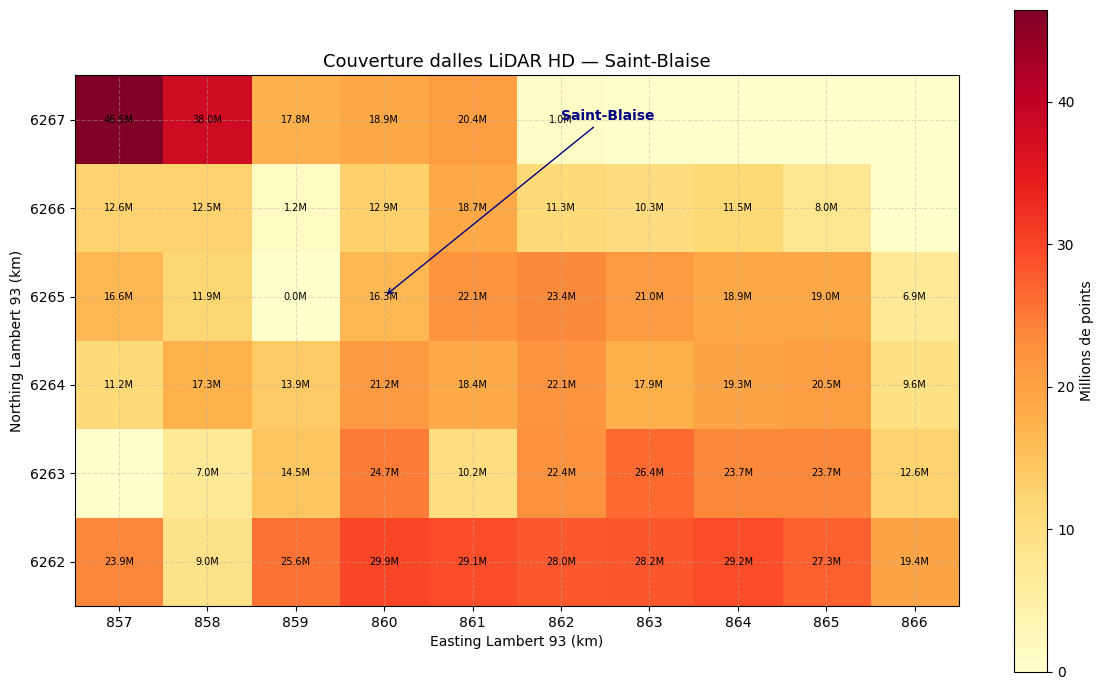

In [22]:
xs = sorted({d["x_km"] for d in infos})
ys = sorted({d["y_km"] for d in infos})
x_idx = {x: i for i, x in enumerate(xs)}
y_idx = {y: i for i, y in enumerate(ys)}

grille = np.zeros((len(ys), len(xs)))
for d in infos:
    grille[y_idx[d["y_km"]], x_idx[d["x_km"]]] = d["nb_points"] / 1e6

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(
    grille,
    origin="lower",
    cmap="YlOrRd",
    extent=[xs[0] - 0.5, xs[-1] + 0.5, ys[0] - 0.5, ys[-1] + 0.5],
    aspect="equal",
)
plt.colorbar(im, ax=ax, label="Millions de points")

for d in infos:
    ax.text(d["x_km"], d["y_km"], f"{d['nb_points']/1e6:.1f}M",
            ha="center", va="center", fontsize=7)

ax.annotate(
    "Saint-Blaise",
    xy=(860, 6265), xytext=(862, 6267),
    fontsize=10, color="navy", fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": "navy"},
)

ax.set_xlabel("Easting Lambert 93 (km)")
ax.set_ylabel("Northing Lambert 93 (km)")
ax.set_title("Couverture dalles LiDAR HD — Saint-Blaise", fontsize=13)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(visible=True, linestyle="--", alpha=0.4)

fig.tight_layout()
fig.savefig(REPORTS_DIR / "coverage_map.png", dpi=150)
plt.show()

## 3. Inspection d'une dalle centrale

Dalle `0860_6265` — couvre les remparts de Saint-Blaise.  
Lecture complète des points (~100 Mo en mémoire).

In [23]:
dalle_path = DALLES_DIR / DALLE_CENTRALE
las = laspy.read(dalle_path)

print(f"Dalle        : {DALLE_CENTRALE}")
print(f"Nb points    : {len(las.x):,}")
print(f"Z min/max    : {float(las.z.min()):.1f} / {float(las.z.max()):.1f} m")
print(f"Format point : {las.point_format.id}")

Dalle        : LHD_FXX_0860_6265_PTS_C_LAMB93_IGN69.copc.laz
Nb points    : 16,332,349
Z min/max    : -11.5 / 82.4 m
Format point : 6


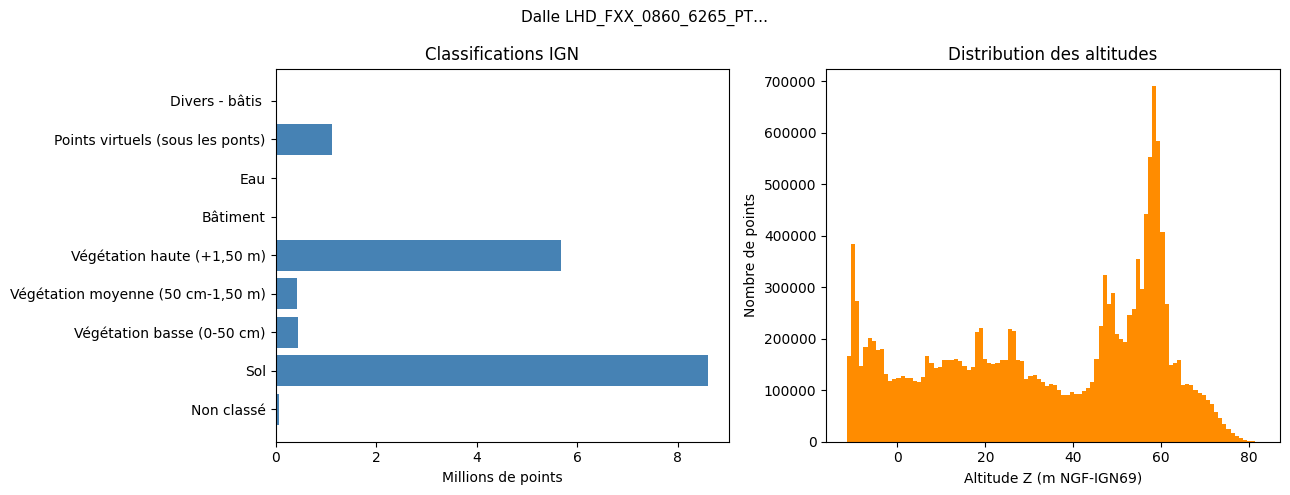

In [24]:
classifications = las.classification
z_values = np.array(las.z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Dalle {DALLE_CENTRALE[:20]}…", fontsize=11)

# Distribution des classifications
classes, counts = np.unique(classifications, return_counts=True)
labels = [CLASSIFICATIONS.get(int(c), f"Classe {c}") for c in classes]
ax1.barh(labels, counts / 1e6, color="steelblue")
ax1.set_xlabel("Millions de points")
ax1.set_title("Classifications IGN")

# Histogramme des altitudes
ax2.hist(z_values, bins=100, color="darkorange", edgecolor="none")
ax2.set_xlabel("Altitude Z (m NGF-IGN69)")
ax2.set_ylabel("Nombre de points")
ax2.set_title("Distribution des altitudes")

fig.tight_layout()
fig.savefig(REPORTS_DIR / "sample_dalle_stats.png", dpi=150)
plt.show()